## Strategy Analysis and Comparison

In [454]:
import sys
import os
sys.path.append(os.path.dirname(os.path.abspath(".")))
import pandas as pd
from datetime import datetime, date
from util.dasutil import das_con
import util.dbutil as DB
db = DB.PSQL(search_path='analytics')
das = das_con(server = "https://dastor-uat.bns/api/gafedas/das")

In [455]:
all_trades = ['uv1m2y+0','uv1m2y-0','uv1m2y+10','uv1m2y-10','uv1m2y+15','uv1m2y-15','uv1m2y+25','uv1m2y-25',
              'uv1m5y+0','uv1m5y-0','uv1m5y+10','uv1m5y-10','uv1m5y+15','uv1m5y-15','uv1m5y+25','uv1m5y-25',
              'uv1m10y+0','uv1m10y-0','uv1m10y+10','uv1m10y-10','uv1m10y+15','uv1m10y-15','uv1m10y+25','uv1m10y-25',
              'uv1m15y+0','uv1m15y-0','uv1m15y+10','uv1m15y-10',
              'uv3m2y+0','uv3m2y-0','uv3m2y+10','uv3m2y-10','uv3m2y+15','uv3m2y-15','uv3m2y+25','uv3m2y-25',
              'uv3m5y+0','uv3m5y-0','uv3m5y+10','uv3m5y-10','uv3m5y+15','uv3m5y-15','uv3m5y+25','uv3m5y-25',
              'uv3m10y+0','uv3m10y-0','uv3m10y+10','uv3m10y-10','uv3m10y+15','uv3m10y-15','uv3m10y+25','uv3m10y-25',
              'uv3m15y+0','uv3m15y-0','uv3m15y+10','uv3m15y-10','uv3m15y+15','uv3m15y-15','uv3m15y+25','uv3m15y-25']

start_date = '2017-10-02'
end_date = '2026-06-19'

backtesting_query = f"""SELECT date, name, -total_pnl/swaprisk as bp_pnl, premium/swaprisk as prem
FROM trade_pnl_view
WHERE name = ANY(ARRAY{all_trades})
AND date >= '{start_date}' AND date <= '{end_date}'
ORDER BY date ASC;
"""

df = db.get(backtesting_query)
df = df.reset_index(drop = True)
df_pivot = df.pivot(index="date", columns="name", values="bp_pnl")
df_pivot

name,uv1m10y+0,uv1m10y+10,uv1m10y+15,uv1m10y+25,uv1m10y-0,uv1m10y-10,uv1m10y-15,uv1m10y-25,uv1m15y+0,uv1m15y+10,...,uv3m2y-15,uv3m2y-25,uv3m5y+0,uv3m5y+10,uv3m5y+15,uv3m5y+25,uv3m5y-0,uv3m5y-10,uv3m5y-15,uv3m5y-25
date,,,,,,,,,,,,,,,,,,,,,
2017-10-02,2.591865,2.499658,1.463184,0.563586,2.517824,1.406008,1.046981,0.484641,2.562072,2.215918,...,0.867721,0.434112,2.970601,3.141948,3.320853,3.606680,2.873674,2.370559,2.016411,1.329875
2017-10-03,2.749633,2.577573,1.592330,0.583838,2.673833,1.331101,0.981042,0.451139,2.930241,2.145725,...,0.893374,0.451996,2.884340,3.098075,3.264246,4.165114,2.789662,2.238261,1.883360,1.223288
2017-10-04,4.076064,2.149122,1.389776,0.487148,3.997194,1.213110,0.817595,0.375957,3.983883,1.766781,...,0.864939,0.438681,2.951674,3.166835,3.402750,4.181126,2.853490,2.309009,1.954222,1.282069
2017-10-05,4.236742,1.918909,1.202465,0.416533,4.160252,1.360700,0.889045,0.406138,3.522077,1.572490,...,1.219433,0.664574,3.244697,3.463922,3.727990,4.306942,3.146584,2.654657,2.292810,1.559357
2017-10-06,3.524851,1.531365,0.896221,0.286693,3.450878,1.428278,0.869153,0.389132,2.901317,1.193930,...,1.197295,0.663733,3.140572,3.380332,3.641359,3.838173,3.043834,2.624824,2.293709,1.594662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-15,-0.213076,0.054838,0.183113,0.298920,-0.294310,-0.129655,0.059874,0.248884,-0.267369,0.075068,...,-0.487501,-0.377019,-0.008706,-0.033858,-0.038592,-0.023812,-0.074677,-0.035762,-0.022192,-0.017040
2026-06-16,-0.366380,-0.251256,-0.085514,0.139873,-0.438715,-0.109901,0.043963,0.142502,-0.332669,-0.130780,...,-1.171556,-0.977750,-0.599681,-0.607468,-0.591211,-0.525198,-0.657781,-0.606366,-0.573975,-0.490051
2026-06-17,-0.224041,-0.055214,0.078705,0.226279,-0.290873,-0.010511,0.168316,0.297942,-0.272374,-0.070602,...,-0.115524,-0.081456,-0.023465,-0.098777,-0.124312,-0.123224,-0.072745,0.023367,0.063168,0.105227


In [456]:
# if we want to select certain frequencies

freq = '1d'
cur_date = pd.to_datetime(start_date).date()
date_range = []

while cur_date <= pd.to_datetime(end_date).date():
    date_range.append(cur_date)
    cur_date = das.das_date_add_tenor(cur_date, freq, "NYC+BMA")[0]

date_range = pd.to_datetime(date_range)

df_pivot.index = pd.to_datetime(df_pivot.index)
df_pivot = df_pivot[df_pivot.index.isin(date_range)]

# premium colelcted in bps

df_prem = df.pivot(index="date", columns="name", values="prem")
df_prem.index = pd.to_datetime(df_prem.index)
df_prem = df_prem[df_prem.index.isin(date_range)]

# formatting strategies and prem df together to be summed
pnl_df = pd.DataFrame()
prem_df = pd.DataFrame()

for i in range(0, len(all_trades), 2):
    if re.split(r"[+-]",all_trades[i])[1] == "0":
        label = re.split(r"[+-]",all_trades[i])[0]
    else:
        label = f"{re.split(r'[+-]',all_trades[i])[0]}.{re.split(r'[+-]',all_trades[i])[1]}"

    pnl_df[label] = df_pivot[all_trades[i]] + df_pivot[all_trades[i+1]]
    prem_df[label] = df_prem[all_trades[i]] + df_prem[all_trades[i+1]]

original_pnl_ts = pnl_df.copy()

# main variables are original_pnl_ts, prem_df

## Strategy Plotting and Visual Analysis

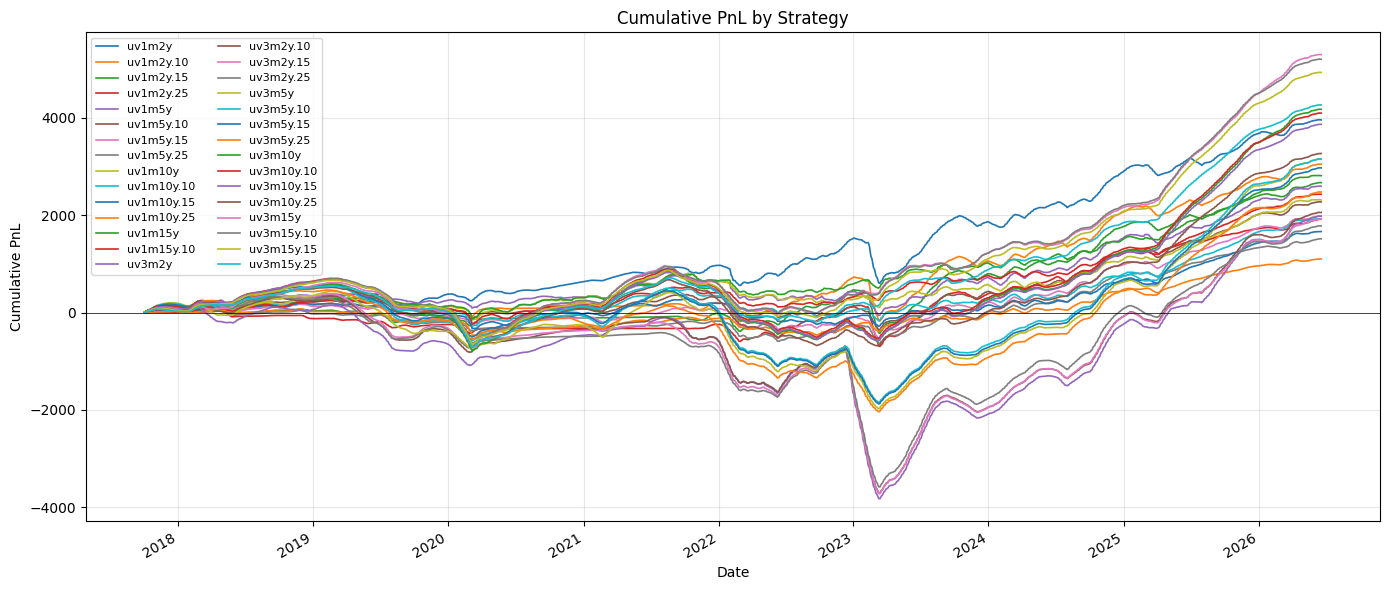

In [457]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 6))
original_pnl_ts.cumsum().plot(ax=ax, lw=1.2)
ax.set_title('Cumulative PnL by Strategy')
ax.set_ylabel('Cumulative PnL')
ax.set_xlabel('Date')
ax.axhline(0, color='black', lw=0.5)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [458]:
# russia ukraine war snapshot
original_pnl_ts.cumsum().loc[datetime(2023, 3, 2)].sort_values(ascending = False)

uv1m2y         787.924488
uv1m15y        526.124105
uv3m15y        390.800689
uv3m15y.10     364.770494
uv1m15y.10     275.863721
uv3m15y.15     258.267890
uv1m10y        149.413741
uv3m15y.25     134.835439
uv1m5y          26.941412
uv1m2y.10        5.085130
uv1m10y.10    -116.264819
uv1m10y.15    -237.811308
uv1m2y.15     -240.235456
uv1m5y.10     -275.315919
uv1m10y.25    -351.797707
uv1m5y.15     -455.006055
uv1m2y.25     -511.681808
uv3m10y.10    -519.011337
uv1m5y.25     -556.014423
uv3m10y.15    -566.681742
uv3m10y       -568.347793
uv3m10y.25    -677.456865
uv3m5y.10    -1799.618385
uv3m5y.15    -1829.003480
uv3m5y       -1925.045090
uv3m5y.25    -1992.102418
uv3m2y.25    -3445.101756
uv3m2y.10    -3573.802682
uv3m2y.15    -3583.602323
uv3m2y       -3684.733775
Name: 2023-03-02 00:00:00, dtype: float64

In [459]:
# final cumulative results by June 2026

final_cum = original_pnl_ts.cumsum().iloc[-1].sort_values(ascending=False)
cumulative_pnl = final_cum.to_frame('cumulative_pnl').reset_index().rename(columns={'index': 'strategy'})
cumulative_pnl.index = range(1, len(cumulative_pnl) + 1)
cumulative_pnl.index.name = 'rank'
cumulative_pnl

,strategy,cumulative_pnl
rank,,
1,uv3m15y,5301.490765
2,uv3m15y.10,5207.015382
3,uv3m15y.15,4936.654468
4,uv3m15y.25,4267.764257
5,uv3m10y,4178.251450
6,uv3m10y.10,4100.718648
7,uv1m2y,3961.306394
8,uv3m10y.15,3869.174938
9,uv3m10y.25,3268.742047


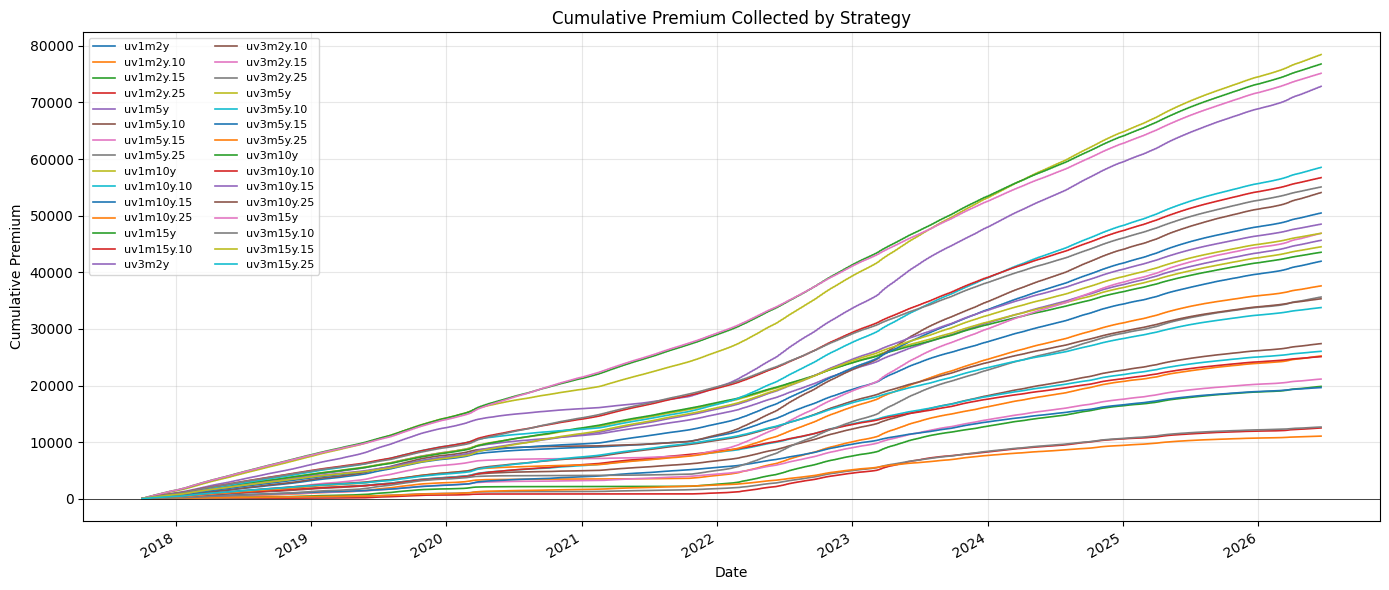

In [460]:
# cumulative premium collected

fig, ax = plt.subplots(figsize=(14, 6))
prem_df.cumsum().plot(ax=ax, lw=1.2)
ax.set_title('Cumulative Premium Collected by Strategy')
ax.set_ylabel('Cumulative Premium')
ax.set_xlabel('Date')
ax.axhline(0, color='black', lw=0.5)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [461]:
# final cumulative premium collected

final_cum_prem = prem_df.cumsum().iloc[-1].sort_values(ascending=False)
cumulative_pnl_prem = final_cum_prem.to_frame('cumulative_pnl_prem').reset_index().rename(
    columns={'index': 'strategy'}
)
cumulative_pnl_prem.index = range(1, len(cumulative_pnl_prem) + 1)
cumulative_pnl_prem.index.name = 'rank'
cumulative_pnl_prem

,strategy,cumulative_pnl_prem
rank,,
1,uv3m5y,78456.210247
2,uv3m10y,76790.762204
3,uv3m15y,75147.258876
4,uv3m2y,72843.624752
5,uv3m5y.10,58530.802188
6,uv3m10y.10,56714.448278
7,uv3m15y.10,55073.273107
8,uv3m2y.10,54080.828041
9,uv3m5y.15,50471.349701


In [506]:
# average pnl
pnl_df.mean().sort_values(ascending = False)

strategy
total         15.548368
uv3m15y        2.382240
uv3m15y.10     2.346034
uv3m15y.15     2.227038
uv3m15y.25     1.930769
uv3m10y        1.843248
uv3m10y.10     1.812544
uv1m2y         1.766363
uv1m15y        1.240132
dtype: float64

In [507]:
# average prem (bps) collected
# can compare different frequencies to see which sees the highest average prem collected

prem_df.describe()

,uv1m2y,uv1m2y.10,uv1m2y.15,uv1m2y.25,uv1m5y,uv1m5y.10,uv1m5y.15,uv1m5y.25,uv1m10y,uv1m10y.10,...,uv3m5y.15,uv3m5y.25,uv3m10y,uv3m10y.10,uv3m10y.15,uv3m10y.25,uv3m15y,uv3m15y.10,uv3m15y.15,uv3m15y.25
count,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,...,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000,2261.000000
mean,18.555367,11.156662,8.776706,5.531917,20.189301,12.117929,9.349658,5.603741,19.682531,11.517261,...,22.322578,16.629069,33.963185,25.083790,21.452767,15.619762,33.236293,24.357927,20.735548,14.934523
std,10.579068,9.328028,8.286140,6.281032,8.313353,7.580946,6.846871,5.207879,6.233162,5.730310,...,12.323416,10.981303,9.733261,9.395551,9.035461,8.046907,8.861715,8.506109,8.152299,7.199864
min,2.875914,0.047394,0.007769,0.000000,5.855535,0.779484,0.264594,0.035162,10.138429,3.283499,...,3.573132,1.562312,18.979415,11.072518,8.215167,4.354335,17.720259,10.022996,7.336252,3.781195
25%,9.676595,2.868924,1.367622,0.256086,13.406898,5.800001,3.593389,1.239292,14.373583,6.674814,...,12.026178,7.291468,25.285039,16.764539,13.495435,8.680455,25.902361,17.275148,13.937130,9.005120
50%,18.147417,10.097276,7.317142,3.675936,18.614102,10.394440,7.573358,3.799787,18.263482,10.140011,...,19.237688,13.467613,31.281981,22.406947,18.750779,13.042018,31.180665,22.241356,18.653801,12.960975
75%,26.352510,17.733148,14.365419,9.137850,26.998476,18.249685,14.764865,9.409481,24.193603,15.533140,...,33.092222,26.019471,42.682697,33.346328,29.265088,22.350824,40.790127,31.524099,27.509920,20.681684
max,62.016378,52.839714,48.633322,40.967983,53.823357,44.478249,40.270753,32.757859,42.982623,33.843802,...,67.280270,59.015422,66.001947,56.530766,52.190460,44.281781,62.057938,52.610824,48.305244,40.507784


## Strategy Statistical Analysis and Metric Comparison

In [463]:
# analyzing each strategy based on mean, std, var_95, max drawdown, downside std, prem collected

original_pnl_ts = original_pnl_ts[datetime(2018, 1, 2).date():]
prem_adj_pnl = original_pnl_ts / prem_df[datetime(2018, 1, 2).date():]

def max_drawdown_val(x):
    cumsum = x.cumsum()
    running_max = cumsum.cummax()
    drawdown = cumsum - running_max
    return drawdown.min()

def downside_std(x):
    neg = x[x < 0]
    return neg.std() if len(neg) > 1 else np.nan

def sortino(x):
    series_mean = x.mean()
    downside = np.minimum(x, 0)
    std_neg = np.sqrt((downside ** 2).mean())
    return (series_mean / std_neg) * np.sqrt(252)

def calmar(x):
    cumulative = x.cumsum()
    mdd = (cumulative - cumulative.cummax()).min()
    return x.mean() * 252 / abs(mdd)

def tail_ratio(x, pct = 0.05):
    upper_p = np.percentile(x, 100 * (1 - pct))
    lower_p = np.percentile(x, 100 * pct)
    return upper_p / lower_p

def cvar(x, pct = 0.05):
    var = np.percentile(x, 100 * pct)
    return x[x <= var].mean()

def cvar_sharpe(x, pct = 0.05):
    c = cvar(x, pct)
    return x.mean() * np.sqrt(252) / abs(c)

weights = pd.Series({
    'mean':            0.5,     # raw daily return, HIGH
    'std':            -0.3,     # total variability, LOW
    'var_95':          0.5,     # HIGH
    'sortino':         1.0,     # core risk-adjusted return, HIGH
    'calmar':          0.8,     # return per unit of drawdown, HIGH
    'tail_ratio':      0.3,     # HIGH
    'cvar':            0.3,     # HIGh
    'cvar_sharpe':     0.8,     # return per unit of tail loss, HIGH
    'max_drawdown_val': 0.6,    # HIGH
    'downside_std':   -0.5,     # downside variability, LOW
    'avg_prem':        0.8      # HIGH
})

def composite_score(strategy_pnl_df, premium_df):
    ranking = pd.DataFrame({
        'mean': strategy_pnl_df.mean(),
        'std': strategy_pnl_df.std(),
        'var_95': strategy_pnl_df.quantile(0.05),
        'sortino': strategy_pnl_df.apply(sortino),
        'calmar': strategy_pnl_df.apply(calmar),
        'tail_ratio': strategy_pnl_df.apply(tail_ratio),
        'cvar': strategy_pnl_df.apply(cvar),
        'cvar_sharpe': strategy_pnl_df.apply(cvar_sharpe),
        'max_drawdown_val': strategy_pnl_df.apply(max_drawdown_val),
        'downside_std': strategy_pnl_df.apply(downside_std),
        'avg_prem': premium_df.mean()
    })

    ranking.index.name = 'strategy'
    z = (ranking - ranking.mean()) / ranking.std()

    ranking['composite'] = (z * weights).sum(axis=1)
    ranking = ranking.sort_values('composite', ascending=False)
    return ranking

### Running Composite Score on the full dataset

In [464]:
# example on the full dataset

score_df = composite_score(original_pnl_ts, prem_df)
score_df['composite']

strategy
uv3m15y       6.991122
uv3m15y.10    6.310885
uv3m15y.15    5.593640
uv1m15y       4.841750
uv3m15y.25    4.233506
uv3m10y       3.829665
uv1m15y.10    3.540398
uv3m10y.10    3.220208
uv3m10y.15    2.737447
uv3m10y.25    1.588095
uv1m10y       1.546653
uv1m2y        1.342596
uv1m5y        1.225393
uv1m10y.10    0.683477
uv1m5y.10     0.446988
uv1m10y.15    0.351430
uv1m5y.15    -0.213428
uv1m2y.10    -0.894628
uv3m5y       -0.960238
uv1m10y.25   -1.007316
uv1m5y.25    -1.080988
uv3m5y.10    -1.400428
uv1m2y.15    -1.513924
uv3m5y.15    -1.828368
uv3m5y.25    -2.707703
uv1m2y.25    -2.753200
uv3m2y       -8.040576
uv3m2y.10    -8.501825
uv3m2y.25    -8.778710
uv3m2y.15    -8.801922
Name: composite, dtype: float64

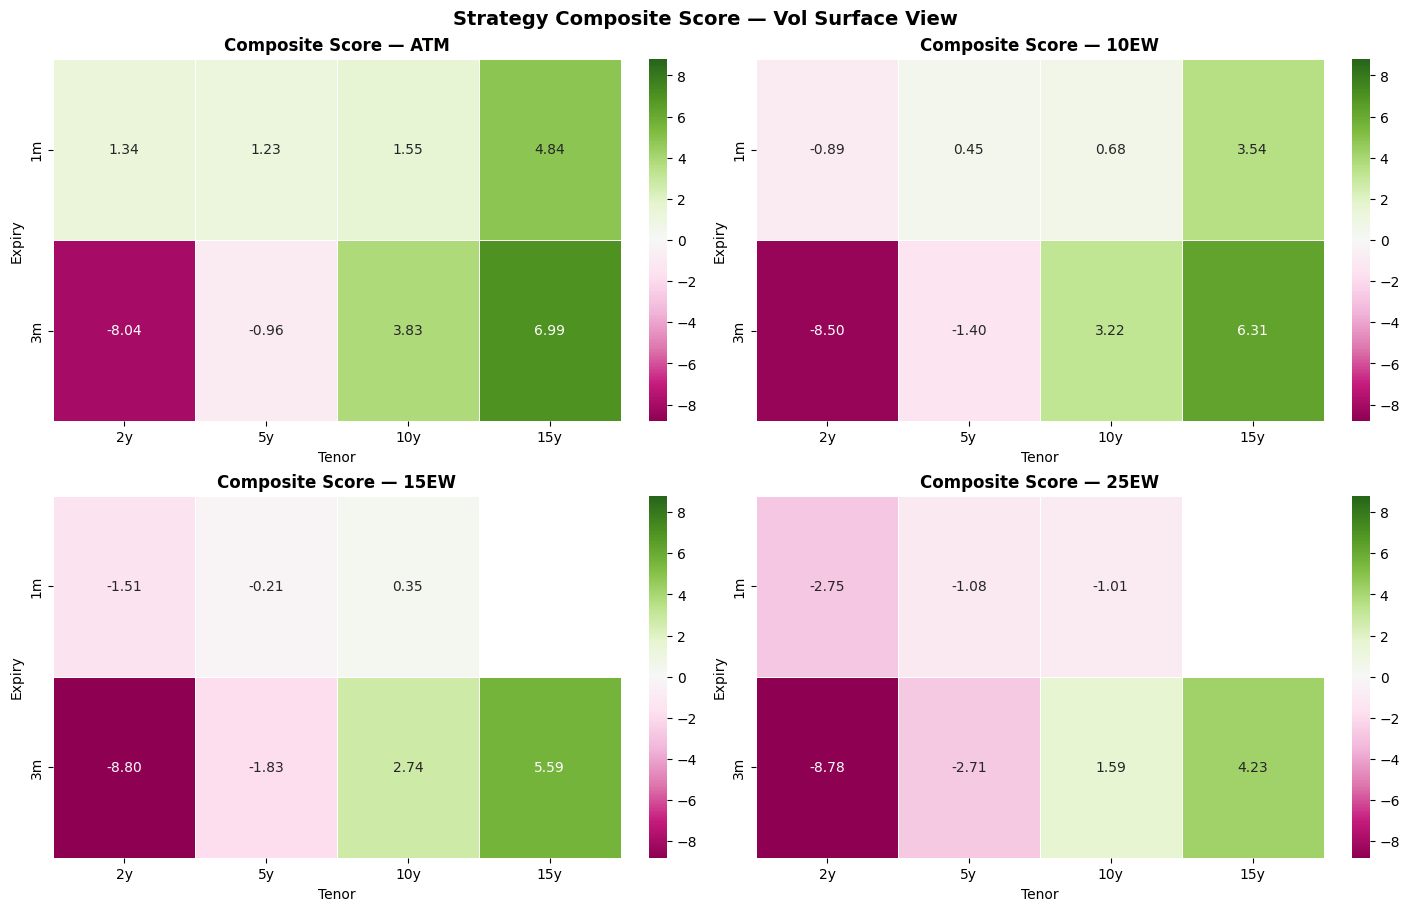

In [465]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = score_df.copy().reset_index()
df = df.rename(columns={df.columns[0]: 'strategy'})   # ensures the index column is named 'strategy'

# ---- 1. Parse the ticker ----
pattern = re.compile(r'uv(\d+m)(\d+y)(?:\.(\d+))?$')

def parse_ticker(s):
    m = pattern.match(s)
    if not m:
        return pd.Series([None, None, None])
    expiry, tenor, skew = m.groups()
    skew_label = f'{skew}ew' if skew else 'atm'
    return pd.Series([expiry, tenor, skew_label])

df[['expiry', 'tenor', 'skew']] = df['strategy'].apply(parse_ticker)

# ---- 2. Set categorical ordering ----
expiry_order = ['1m', '3m']
tenor_order  = ['2y', '5y', '10y', '15y']
skew_order   = ['atm', '10ew', '15ew', '25ew']

df['expiry'] = pd.Categorical(df['expiry'], categories=expiry_order, ordered=True)
df['tenor']  = pd.Categorical(df['tenor'],  categories=tenor_order,  ordered=True)
df['skew']   = pd.Categorical(df['skew'],   categories=skew_order,   ordered=True)

# ---- 3. Build 2x2 grid of heatmaps ----
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

vmin, vmax = df['composite'].min(), df['composite'].max()
abs_max = max(abs(vmin), abs(vmax))

for ax, sk in zip(axes.flat, skew_order):
    sub = df[df['skew'] == sk]
    pivot = sub.pivot(index='expiry', columns='tenor', values='composite')
    pivot = pivot.reindex(index=expiry_order, columns=tenor_order)

    sns.heatmap(
        pivot,
        annot=True, fmt='.2f',
        cmap='PiYG',
        center=0,
        vmin=-abs_max, vmax=abs_max,
        cbar=True,
        linewidths=0.5, linecolor='white',
        ax=ax,
    )
    ax.set_title(f'Composite Score — {sk.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tenor')
    ax.set_ylabel('Expiry')

fig.suptitle('Strategy Composite Score — Vol Surface View', fontsize=14, fontweight='bold')
plt.show()

In [466]:
# ratio comparison

print(ranking['sortino'].sort_values(ascending = False).head(5))
print("....")
print(ranking['calmar'].sort_values(ascending = False).head(5))
print("....")
print(ranking['cvar_sharpe'].sort_values(ascending = False).head(5))

strategy
uv3m15y.10    10.323
uv3m15y       10.077
uv3m15y.15     9.985
uv3m15y.25     9.140
uv3m10y.10     7.135
Name: sortino, dtype: float64
....
strategy
uv1m15y       0.691
uv1m15y.10    0.561
uv1m2y        0.476
uv3m15y       0.442
uv3m15y.10    0.438
Name: calmar, dtype: float64
....
strategy
uv3m15y.10    2.772
uv3m15y       2.733
uv3m15y.15    2.683
uv3m15y.25    2.441
uv3m10y.10    1.991
Name: cvar_sharpe, dtype: float64


### Running Composite Score on Prem-adjusted Dataset

In [467]:
prem_adj_pnl = original_pnl_ts / prem_df[datetime(2018, 1, 2).date():]
prem_adj_score_df = composite_score(prem_adj_pnl, prem_df)
prem_adj_score_df['composite'].sort_values(ascending=False).round(3)

C:\Users\s1799275\AppData\Roaming\Python\Python311\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\s1799275\AppData\Roaming\Python\Python311\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\s1799275\AppData\Roaming\Python\Python311\site-packages\numpy\_core\fromnumeric.py:54: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)
c:\Users\s1799275\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


strategy
uv1m2y         6.499
uv3m15y        6.233
uv1m15y        4.917
uv3m15y.10     4.721
uv3m10y        4.669
uv3m15y.15     3.610
uv3m10y.10     3.386
uv1m5y         2.870
uv1m10y        2.867
uv3m10y.15     2.555
uv3m5y         2.225
uv1m15y.10     2.183
uv3m15y.25     1.288
uv3m5y.10      1.049
uv1m10y.10     0.715
uv3m10y.25     0.539
uv3m2y         0.180
uv3m5y.15      0.046
uv1m5y.10     -0.176
uv3m2y.10     -0.384
uv1m10y.15    -0.849
uv1m2y.10     -1.797
uv3m2y.15     -1.997
uv3m5y.25     -2.854
uv1m5y.15     -3.799
uv3m2y.25     -5.608
uv1m2y.25     -5.728
uv1m10y.25    -6.008
uv1m2y.15     -7.131
uv1m5y.25    -14.221
Name: composite, dtype: float64

## Block Bootstrap of Scores

In [468]:
strat_cols = list(pnl_df.columns)

def moving_block_bootstrap(df, sample_length, block_length, seed=None):
    rng = np.random.default_rng(seed)
    T = len(df)
    
    if block_length >= T:
        raise ValueError("Block length must be smaller than dataframe length")
    
    n_blocks = int(np.ceil(sample_length / block_length))
    max_start = T - block_length
    starts = rng.integers(0, max_start + 1, size=n_blocks)
    
    # Build sample, keeping original dates as a column
    pieces = []
    for s in starts:
        block = df.iloc[s:s + block_length].copy()
        block['original_date'] = df.index[s:s + block_length]
        block['block_id']      = s
        pieces.append(block)
    
    sample = pd.concat(pieces, ignore_index=True)
    sample = sample.iloc[:sample_length].reset_index(drop=True)
    
    # Add a synthetic "bootstrap day" index for clarity
    sample.insert(0, 'boot_day', range(1, len(sample) + 1))
    
    return sample

In [469]:
# 2261 observations total, sample_length will represent a little under 20% of the full dataset

bootstrap_instances = 500
bootstrapped_scores = []

for b in range(bootstrap_instances):
    rng = np.random.randint(1000)
    boot = moving_block_bootstrap(original_pnl_ts, sample_length=500, block_length=45, seed = rng)

    bootstrapped_pnl = boot[strat_cols]
    bootstrapped_prem = prem_df.loc[boot['original_date']].reset_index(drop = True)

    bootstrapped_scoring = composite_score(bootstrapped_pnl, bootstrapped_prem)['composite']

    bootstrapped_scores.append(bootstrapped_scoring.to_frame(name=b).T)

bootstrap_summary = pd.concat(bootstrapped_scores, ignore_index=True)
bootstrap_summary.index.name = 'iteration'
bootstrap_summary.sum().sort_values(ascending = False)

strategy
uv3m15y       2035.335795
uv3m15y.10    1900.065952
uv3m15y.15    1669.259461
uv3m15y.25    1384.889096
uv1m15y       1141.246251
uv1m2y         958.443959
uv1m15y.10     791.918373
uv3m10y        663.275167
uv3m10y.10     478.397071
uv3m10y.15     351.758632
uv1m5y         193.678307
uv1m10y        153.906591
uv1m2y.10       81.890066
uv3m10y.25      17.771002
uv1m2y.15      -33.434377
uv1m5y.10     -149.145197
uv1m2y.25     -191.255002
uv1m10y.10    -210.350300
uv1m5y.15     -238.053465
uv1m10y.15    -285.064284
uv1m5y.25     -305.167677
uv3m5y        -320.672028
uv3m5y.10     -397.465622
uv1m10y.25    -450.978507
uv3m5y.15     -508.291389
uv3m5y.25     -883.901058
uv3m2y.25    -1936.410330
uv3m2y.10    -1953.877024
uv3m2y       -1955.211822
uv3m2y.15    -2002.557642
dtype: float64

In [470]:
# prem adj bootstrap

bootstrap_instances = 500
bootstrapped_scores = []

for b in range(bootstrap_instances):
    rng = np.random.randint(1000)
    boot = moving_block_bootstrap(prem_adj_pnl, sample_length=500, block_length=45, seed = rng)

    bootstrapped_pnl = boot[strat_cols]
    bootstrapped_prem = prem_df.loc[boot['original_date']].reset_index(drop = True)

    bootstrapped_scoring = composite_score(bootstrapped_pnl, bootstrapped_prem)['composite']

    bootstrapped_scores.append(bootstrapped_scoring.to_frame(name=b).T)

bootstrap_summary = pd.concat(bootstrapped_scores, ignore_index=True)
bootstrap_summary.index.name = 'iteration'
bootstrap_summary.sum().sort_values(ascending = False).round(3)

c:\Users\s1799275\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\s1799275\AppData\Local\Temp\ipykernel_34956\860714747.py:20: RuntimeWarning: invalid value encountered in scalar divide
  return (series_mean / std_neg) * np.sqrt(252)
C:\Users\s1799275\AppData\Local\Temp\ipykernel_34956\860714747.py:25: RuntimeWarning: invalid value encountered in scalar divide
  return x.mean() * 252 / abs(mdd)
c:\Users\s1799275\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\s1799275\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\s1799275\AppData\Local\Temp\ipykernel_349

strategy
uv3m15y       2491.484
uv3m15y.10    1912.059
uv1m2y        1861.564
uv3m10y       1728.436
uv3m15y.15    1456.774
uv1m15y       1388.306
uv3m10y.10    1195.064
uv3m5y         979.808
uv1m5y         898.078
uv1m10y        862.447
uv3m10y.15     848.513
uv3m15y.25     555.270
uv3m5y.10      466.404
uv3m2y         426.854
uv1m15y.10     360.986
uv3m5y.15      119.231
uv3m2y.10       68.840
uv3m10y.25      40.320
uv1m10y.10    -121.730
uv1m5y.10     -162.743
uv3m2y.15     -553.452
uv1m2y.10     -562.224
uv1m10y.15    -739.842
uv1m5y.15     -880.181
uv3m5y.25     -898.684
uv1m2y.15    -1887.353
uv3m2y.25    -1998.385
uv1m10y.25   -2694.971
uv1m5y.25    -3357.708
uv1m2y.25    -3803.166
dtype: float64

## Analyzing Top-performing Strategies

- 3m15y, atm, 10ew, 15ew, 25ew
- 1m2y
- 1m15y
- 3m10y, atm and 10 ew

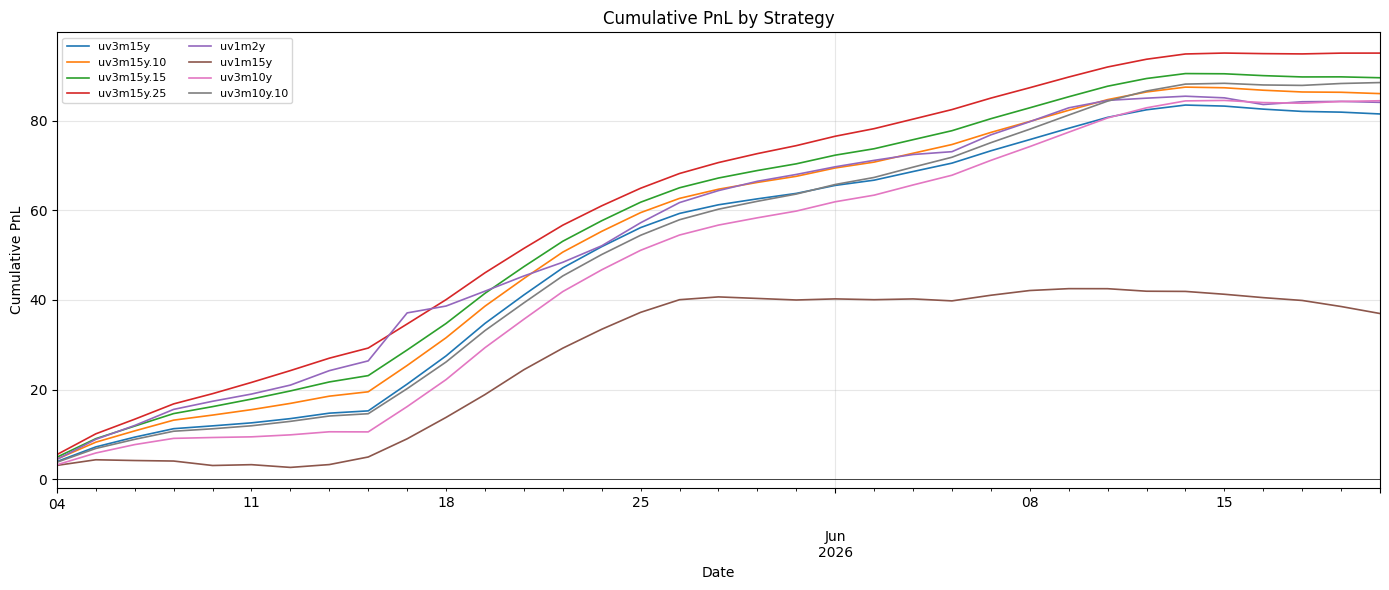

In [471]:
selected_strategies = ['uv3m15y', 'uv3m15y.10', 'uv3m15y.15', 'uv3m15y.25',
                       'uv1m2y', 'uv1m15y', 'uv3m10y', 'uv3m10y.10']

fig, ax = plt.subplots(figsize=(14, 6))
original_pnl_ts[datetime(2026, 5, 2):][selected_strategies].cumsum().plot(ax=ax, lw=1.2)
# original_pnl_ts[datetime(2026, 1, 2):][selected_strategies].plot(ax=ax, lw=1.2)
# original_pnl_ts[selected_strategies].cumsum().plot(ax=ax, lw=1.2)
ax.set_title('Cumulative PnL by Strategy')
ax.set_ylabel('Cumulative PnL')
ax.set_xlabel('Date')
ax.axhline(0, color='black', lw=0.5)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Regime Analysis

In [472]:
import re
import pandas as pd
import numpy as np

pnl_df = original_pnl_ts[selected_strategies].copy()

pnl_df['total'] = original_pnl_ts[selected_strategies].sum(axis = 1)
# pnl_df['std'] = pnl_df['total'].rolling(63).std()
# pnl_df['tail_ratio'] = pnl_df['total'].rolling(63).apply(tail_ratio)
# pnl_df['var_95'] = pnl_df['total'].rolling(63).quantile(0.05)
# pnl_df['max_drawdown_val'] = pnl_df['total'].rolling(63).apply(max_drawdown_val)

pnl_df = pnl_df[datetime(2018, 1, 2):]

In [473]:
vars_of_interest = ['uv1m2y', 'uv1m5y', 'uv1m10y', 'uv3m2y', 'uv3m5y', 'uv3m10y',
                    'uv1y2y', 'uv1y5y', 'uv1y10y', 'u2y', 'u5y', 'u10y',
                    'u1m2y', 'u1m5y', 'u1m10y', 'u3m2y', 'u3m5y', 'u3m10y', 'u1y2y', 'u1y5y', 'u1y10y']

variables_query = f"""SELECT date, name, value FROM prod.series_view WHERE name = ANY(ARRAY{vars_of_interest}) and value_name = 'value'
AND date >= '{start_date}' AND date <= '{end_date}'
ORDER BY date ASC;
"""

var_df = db.get(variables_query).reset_index(drop = True)
var_df_pivot = var_df.pivot(index="date", columns="name", values="value")
var_df_pivot

name,u10y,u1m10y,u1m2y,u1m5y,u1y10y,u1y2y,u1y5y,u2y,u3m10y,u3m2y,...,u5y,uv1m10y,uv1m2y,uv1m5y,uv1y10y,uv1y2y,uv1y5y,uv3m10y,uv3m2y,uv3m5y
date,,,,,,,,,,,,,,,,,,,,,
2017-10-02,1.974279,1.985635,1.541470,1.758518,2.077290,1.725597,1.889305,1.515590,2.004598,1.585753,...,1.741784,62.429726,39.711868,57.754489,67.579010,52.549560,65.334620,61.895756,41.496995,57.531447
2017-10-03,1.967329,1.978523,1.540888,1.745801,2.071058,1.712589,1.873296,1.516816,1.998061,1.584286,...,1.729904,62.871785,41.211602,58.294548,67.539047,52.871299,65.309113,61.864635,41.935378,57.518119
2017-10-04,1.967718,1.978553,1.543936,1.748762,2.071154,1.717607,1.878740,1.520382,1.999022,1.588550,...,1.733224,60.613037,40.640452,57.194523,67.538812,52.816434,65.027933,61.848147,41.870852,58.022262
2017-10-05,1.982566,1.993030,1.564209,1.770536,2.084271,1.739815,1.897557,1.539102,2.012748,1.607466,...,1.755041,61.132957,41.511247,58.949261,68.028356,53.254966,65.626308,62.742299,43.535883,59.131351
2017-10-06,1.997455,2.008890,1.582195,1.792087,2.098104,1.760896,1.920050,1.555031,2.027505,1.625812,...,1.774738,60.174267,39.887831,57.655603,67.508069,53.306747,65.378178,61.579236,42.446053,58.002650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-15,4.066975,4.073622,3.931136,3.913887,4.130199,3.925980,3.947929,3.922646,4.086809,3.944910,...,3.908267,65.519640,86.080077,76.440639,77.910722,93.516593,85.729118,69.094033,85.970941,79.042137
2026-06-16,4.019579,4.026255,3.910334,3.875533,4.076734,3.883386,3.897584,3.903066,4.037770,3.919446,...,3.870503,63.240513,81.523009,73.930523,77.077824,91.000098,84.798787,67.709139,82.673137,76.199460
2026-06-17,4.050631,4.056505,4.030473,3.947987,4.091492,3.975518,3.946366,4.020214,4.067046,4.042099,...,3.943215,64.526997,81.451061,74.377119,77.084803,91.132408,84.418177,68.536598,84.566253,78.061356


In [474]:
# add transformations/ratios of core variables
import numpy as np

helper_df = pd.DataFrame()

fwd_rates_list = ['u1m2y', 'u1m5y', 'u1m10y', 
                  'u3m2y', 'u3m5y', 'u3m10y',
                  'u1y2y', 'u1y5y', 'u1y10y']

iv_list = ['uv1m2y', 'uv1m5y', 'uv1m10y', 
           'uv3m2y', 'uv3m5y', 'uv3m10y',
           'uv1y2y', 'uv1y5y', 'uv1y10y']

for col in range(len(fwd_rates_list)):
    realized_vol_21 = var_df_pivot[fwd_rates_list[col]].diff().rolling(window=21).std() * np.sqrt(252) * 100
    helper_df[f"{fwd_rates_list[col]}_rv_1m"] = realized_vol_21
    helper_df[f"{fwd_rates_list[col]}_rv_1m"] = helper_df[f"{fwd_rates_list[col]}_rv_1m"].fillna(0)

    realized_vol_63 = var_df_pivot[fwd_rates_list[col]].diff().rolling(window=63).std() * np.sqrt(252) * 100
    helper_df[f"{fwd_rates_list[col]}_rv_3m"] = realized_vol_63
    helper_df[f"{fwd_rates_list[col]}_rv_3m"] = helper_df[f"{fwd_rates_list[col]}_rv_3m"].fillna(0)

    vvol_21 = var_df_pivot[iv_list[col]].diff().rolling(window=21).std() * np.sqrt(252)
    helper_df[f"{iv_list[col]}_vvol_1m"] = vvol_21

    vvol_63 = var_df_pivot[iv_list[col]].diff().rolling(window=63).std() * np.sqrt(252)
    helper_df[f"{iv_list[col]}_vvol_3m"] = vvol_63

for rate in ['u2y', 'u5y', 'u10y']:
    rolling_mean_1m = var_df_pivot[rate].rolling(window=21).mean()
    rolling_std_1m = var_df_pivot[rate].rolling(window=21).std()
    helper_df[f'{rate}_zscore_1m'] = (var_df_pivot[rate] - rolling_mean_1m) / rolling_std_1m

    rolling_mean_3m = var_df_pivot[rate].rolling(window=63).mean()
    rolling_std_3m = var_df_pivot[rate].rolling(window=63).std()
    helper_df[f'{rate}_zscore_3m'] = (var_df_pivot[rate] - rolling_mean_3m) / rolling_std_3m

helper_df['u2s10s'] = var_df_pivot['u10y'] - var_df_pivot['u2y']
helper_df['uv3ms1ys'] = var_df_pivot['uv1y10y'] - var_df_pivot['uv3m10y']
helper_df['uv3ms2ys'] = var_df_pivot['uv1y2y'] - var_df_pivot['uv3m2y']

# vol risk prem
helper_df['uv1m2y_1m_ratio'] = var_df_pivot['uv1m2y'] / helper_df['u1m2y_rv_1m']
helper_df['uv1m2y_3m_ratio'] = var_df_pivot['uv1m2y'] / helper_df['u1m2y_rv_3m']

helper_df['uv1m5y_1m_ratio'] = var_df_pivot['uv1m5y'] / helper_df['u1m5y_rv_1m']
helper_df['uv1m5y_3m_ratio'] = var_df_pivot['uv1m5y'] / helper_df['u1m5y_rv_3m']

helper_df['uv1m10y_1m_ratio'] = var_df_pivot['uv1m10y'] / helper_df['u1m10y_rv_1m']
helper_df['uv1m10y_3m_ratio'] = var_df_pivot['uv1m10y'] / helper_df['u1m10y_rv_3m']

In [475]:
# var_df_pivot = var_df_pivot[]
from datetime import datetime

df_pivot = df_pivot[datetime(2018, 1, 2).date():]
var_df_pivot = var_df_pivot[datetime(2018, 1, 2).date():]
helper_df = helper_df[datetime(2018, 1, 2).date():]
macro_df = pd.concat([var_df_pivot, helper_df], axis = 1)

pnl_df = pnl_df[datetime(2018, 1, 2).date():]

# full_X = pd.concat([var_df_pivot, helper_df], axis = 1)

## Pre-Processing

In [476]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# X_raw = full_X.copy()
X_raw = pnl_df.copy()
X_scaled = scaler.fit_transform(X_raw.values)

## Hidden Markov Model

In [477]:
from hmmlearn.hmm import GaussianHMM

def fit_hmm(X, n_states, n_iter = 1000, n_init = 10, seed = 42):

    best_model, best_ll = None, -np.inf
    for i in range(n_init):
        model = GaussianHMM(n_components = n_states,
                            covariance_type = "diag",
                            n_iter = n_iter,
                            tol = 1e-4,
                            random_state = seed + i)
        model.fit(X)
        ll = model.score(X) * len(X)
        if ll > best_ll:
            best_ll, best_model = ll, model
    return best_model, best_ll

def bic(log_likelihood, n_params, T):
    return -2 * log_likelihood + n_params * np.log(T)

def n_params_gaussian_hmm(n_states, n_features):
    transition = n_states * (n_states - 1)
    init = n_states - 1
    means = n_states * n_features
    cov = n_states * n_features # diag cov type
    return transition + init + means + cov

In [478]:
T, K = X_scaled.shape
bic_scores, models_by_k = {}, {}

for k in range(2, 7):
    model, ll = fit_hmm(X_scaled, k)
    n_p = n_params_gaussian_hmm(k, K)
    b = bic(ll, n_p, T)
    bic_scores[k] = b
    models_by_k[k] = model

best_k = min(bic_scores, key = bic_scores.get)

# select best model
final_model = models_by_k[best_k]
hidden_states = final_model.predict(X_scaled)
state_probs = final_model.predict_proba(X_scaled)

## Ranking each regime from most favorable to least

In [479]:
weights_dict = weights[:10].to_dict()

results = pnl_df.copy()

results['states'] = hidden_states

regime_profile = results.groupby('states').agg([('mean','mean'),
                                                ('std','std'),
                                                ('var_95', lambda x: x.quantile(0.05)),
                                                # ('sortino', sortino),
                                                # ('calmar', calmar),
                                                ('tail_ratio', tail_ratio),
                                                # ('cvar', cvar),
                                                # ('cvar_sharpe', cvar_sharpe),
                                                ('max_drawdown_val', max_drawdown_val),
                                                ('downside_std', downside_std)])
regime_profile = regime_profile.replace([np.inf, -np.inf], 0).fillna(0)

regime_z = (regime_profile - regime_profile.mean()) / regime_profile.std()

regime_weights = pd.Series([weights_dict.get(col[1], 0) for col in regime_z.columns],
                           index=regime_z.columns)

regime_weighted = regime_z * regime_weights
regime_weighted['composite'] = regime_weighted.sum(axis=1)
regime_weighted = regime_weighted.sort_values('composite', ascending=False)
regime_weighted

strategy   uv3m15y                                                  \
              mean       std    var_95 tail_ratio max_drawdown_val   
states                                                               
5         0.669653 -0.030778  0.522730   0.105368         0.374790   
0         0.343189  0.137093  0.323273   0.148305         0.374790   
2         0.108213  0.147908  0.176643   0.436816         0.366649   
4        -0.057398  0.222510  0.059148  -0.441766         0.365848   
1        -0.304783  0.111800 -0.185645  -0.122578        -0.464895   
3        -0.758874 -0.588533 -0.896149  -0.126146        -1.017183   

strategy              uv3m15y.10                                 ...  \
         downside_std       mean       std    var_95 tail_ratio  ...   
states                                                           ...   
5            0.431220   0.674959 -0.032444  0.521329   0.174444  ...   
0            0.431220   0.336551  0.147357  0.320920   0.180423  ...   
2           -0.255093   0.106295  0.184367  0.179990   0.306049  ...   
4            0.248592  -0.055824  0.202645  0.064131  -0.533965  ...   
1            0.010730  -0.304221  0.085352 -0.190612  -0.054152  ...   
3           -0.866668  -0.757759 -0.587276 -0.895759  -0.072798  ...   

strategy uv3m10y.10                                   total            \
         tail_ratio max_drawdown_val downside_std      mean       std   
states                                                                  
5         -0.074931         0.384457     0.419924  0.663055 -0.094675   
0         -0.071097         0.384457     0.419924  0.327972  0.114546   
2          0.605872         0.359107    -0.035586  0.102719  0.215817   
4         -0.187530         0.361175     0.210825 -0.043817  0.219095   
1         -0.137718        -0.483705    -0.097412 -0.261198  0.111667   
3         -0.134596        -1.005490    -0.917674 -0.788731 -0.566451   

strategy                                                     composite  
            var_95 tail_ratio max_drawdown_val downside_std             
states                                                                  
5         0.524804   0.137943         0.358248     0.349638  18.634924  
0         0.300858   0.194577         0.358248     0.349638  13.098999  
2         0.175575   0.375327         0.357009     0.142514  10.785803  
4         0.059923  -0.473881         0.344306     0.184421   3.910614  
1        -0.152018  -0.129383        -0.326663    -0.052328  -6.922558  
3        -0.909142  -0.104584        -1.091149    -0.973883 -39.507782  

[6 rows x 55 columns]

In [508]:
# renaming labels

descriptive_labels = ['best', 'good', 'neutral_good', 'neutral_poor', 'poor', 'stanky']
remap = dict(zip(regime_weighted.index, descriptive_labels[:len(regime_weighted)]))
regime_weighted.index = regime_weighted.index.map(remap)
regime_weighted

strategy       uv3m15y                                                  \
                  mean       std    var_95 tail_ratio max_drawdown_val   
states                                                                   
best          0.669653 -0.030778  0.522730   0.105368         0.374790   
good          0.343189  0.137093  0.323273   0.148305         0.374790   
neutral_good  0.108213  0.147908  0.176643   0.436816         0.366649   
neutral_poor -0.057398  0.222510  0.059148  -0.441766         0.365848   
poor         -0.304783  0.111800 -0.185645  -0.122578        -0.464895   
stanky       -0.758874 -0.588533 -0.896149  -0.126146        -1.017183   

strategy                  uv3m15y.10                                 ...  \
             downside_std       mean       std    var_95 tail_ratio  ...   
states                                                               ...   
best             0.431220   0.674959 -0.032444  0.521329   0.174444  ...   
good             0.431220   0.336551  0.147357  0.320920   0.180423  ...   
neutral_good    -0.255093   0.106295  0.184367  0.179990   0.306049  ...   
neutral_poor     0.248592  -0.055824  0.202645  0.064131  -0.533965  ...   
poor             0.010730  -0.304221  0.085352 -0.190612  -0.054152  ...   
stanky          -0.866668  -0.757759 -0.587276 -0.895759  -0.072798  ...   

strategy     uv3m10y.10                                   total            \
             tail_ratio max_drawdown_val downside_std      mean       std   
states                                                                      
best          -0.074931         0.384457     0.419924  0.663055 -0.094675   
good          -0.071097         0.384457     0.419924  0.327972  0.114546   
neutral_good   0.605872         0.359107    -0.035586  0.102719  0.215817   
neutral_poor  -0.187530         0.361175     0.210825 -0.043817  0.219095   
poor          -0.137718        -0.483705    -0.097412 -0.261198  0.111667   
stanky        -0.134596        -1.005490    -0.917674 -0.788731 -0.566451   

strategy                                                         composite  
                var_95 tail_ratio max_drawdown_val downside_std             
states                                                                      
best          0.524804   0.137943         0.358248     0.349638  18.634924  
good          0.300858   0.194577         0.358248     0.349638  13.098999  
neutral_good  0.175575   0.375327         0.357009     0.142514  10.785803  
neutral_poor  0.059923  -0.473881         0.344306     0.184421   3.910614  
poor         -0.152018  -0.129383        -0.326663    -0.052328  -6.922558  
stanky       -0.909142  -0.104584        -1.091149    -0.973883 -39.507782  

[6 rows x 55 columns]

In [481]:
hidden_states_labeled = pd.Series(hidden_states).map(remap).values
macro_df['states'] = hidden_states_labeled
remap

{5: 'best',
 0: 'good',
 2: 'neutral_good',
 4: 'neutral_poor',
 1: 'poor',
 3: 'stanky'}

In [482]:
hidden_states_labeled = pd.Series(hidden_states).map(remap).values
macro_df['states'] = hidden_states_labeled

# regime_macro_profile = (macro_df.groupby('states').agg(['mean', 'median', 'std', lambda x: x.quantile(0.05),
#                                                         lambda x: x.quantile(0.95),
#                                                         lambda x: x.quantile(0.75) - x.quantile(0.25),
#                                                         lambda x: x.max(),
#                                                         lambda x: x.min()]))

regime_macro_metric = macro_df.groupby('states').mean() # can be std, median, etc.

regime_macro_rates = regime_macro_metric[fwd_rates_list + ['u2y', 'u5y', 'u10y']]
regime_macro_ivs = regime_macro_metric[['uv1m2y', 'uv1m5y', 'uv1m10y', 'uv3m2y', 'uv3m5y', 'uv3m10y', 'uv1y2y', 'uv1y5y', 'uv1y10y']]
regime_macro_rvs = regime_macro_metric[['u1m2y_rv_1m', 'u1m2y_rv_3m', 'u1m5y_rv_1m', 'u1m5y_rv_3m', 'u1m10y_rv_1m', 'u1m10y_rv_3m',
                                       'u3m2y_rv_3m', 'u3m2y_rv_3m', 'u3m5y_rv_3m', 'u3m5y_rv_3m', 'u3m10y_rv_3m', 'u3m10y_rv_3m',
                                       'u1y2y_rv_3m', 'u1y2y_rv_3m', 'u1y5y_rv_3m', 'u1y5y_rv_3m', 'u1y10y_rv_3m', 'u1y10y_rv_3m']]
regime_macro_vvol = regime_macro_metric[['uv1m2y_vvol_1m', 'uv1m2y_vvol_3m', 'uv1m5y_vvol_1m', 'uv1m5y_vvol_3m', 'uv1m10y_vvol_1m', 'uv1m10y_vvol_3m',
                                        'uv3m2y_vvol_1m', 'uv3m2y_vvol_3m', 'uv3m5y_vvol_1m', 'uv3m5y_vvol_3m', 'uv3m10y_vvol_1m', 'uv3m10y_vvol_3m',
                                        'uv1y2y_vvol_1m', 'uv1y2y_vvol_3m', 'uv1y5y_vvol_1m', 'uv1y5y_vvol_3m', 'uv1y10y_vvol_1m', 'uv1y10y_vvol_3m']]
regime_macro_rates_zscore = regime_macro_metric[['u2y_zscore_1m', 'u2y_zscore_3m', 'u5y_zscore_1m', 'u5y_zscore_3m', 'u10y_zscore_1m', 'u10y_zscore_3m']]
regime_macro_u2s10s = regime_macro_metric[['u2s10s']]
regime_macro_vol_curve = regime_macro_metric[['uv3ms1ys', 'uv3ms2ys']]
regime_macro_1m_vrp = regime_macro_metric[['uv1m2y_1m_ratio', 'uv1m5y_1m_ratio', 'uv1m10y_1m_ratio']]
regime_macro_3m_vrp = regime_macro_metric[['uv1m2y_3m_ratio', 'uv1m5y_3m_ratio', 'uv1m10y_3m_ratio']]

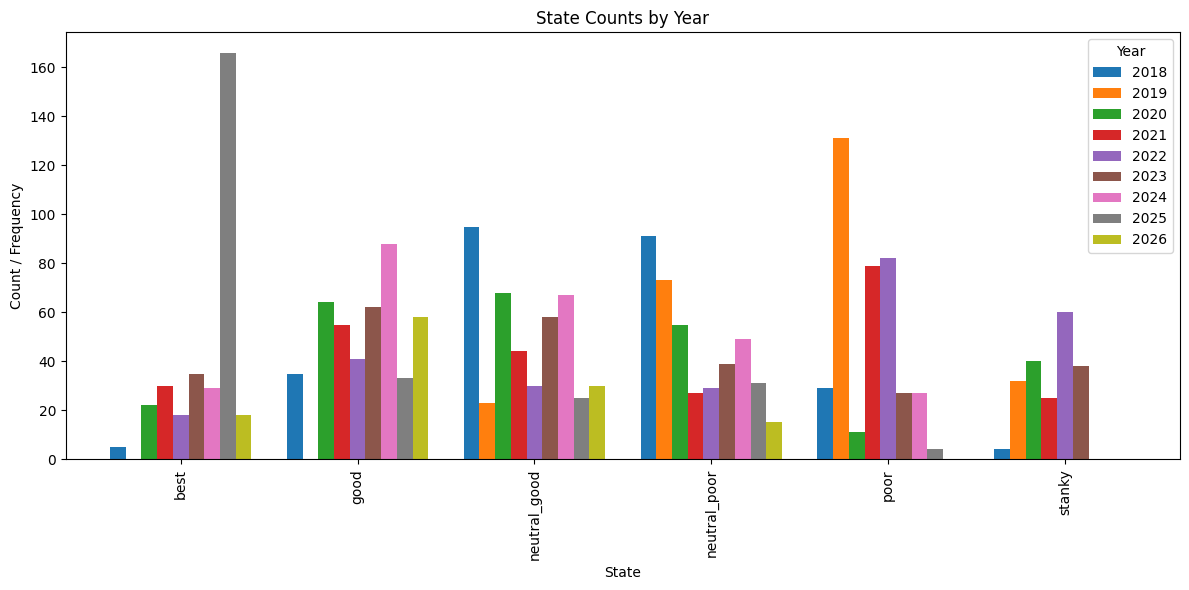

In [483]:
state_year_counts = (
    macro_df.groupby(["states", pd.to_datetime(macro_df.index).year])
    .size()
    .unstack(fill_value=0)
)

ax = state_year_counts.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

ax.set_xlabel("State")
ax.set_ylabel("Count / Frequency")
ax.set_title("State Counts by Year")
ax.legend(title="Year")
plt.tight_layout()
plt.show()


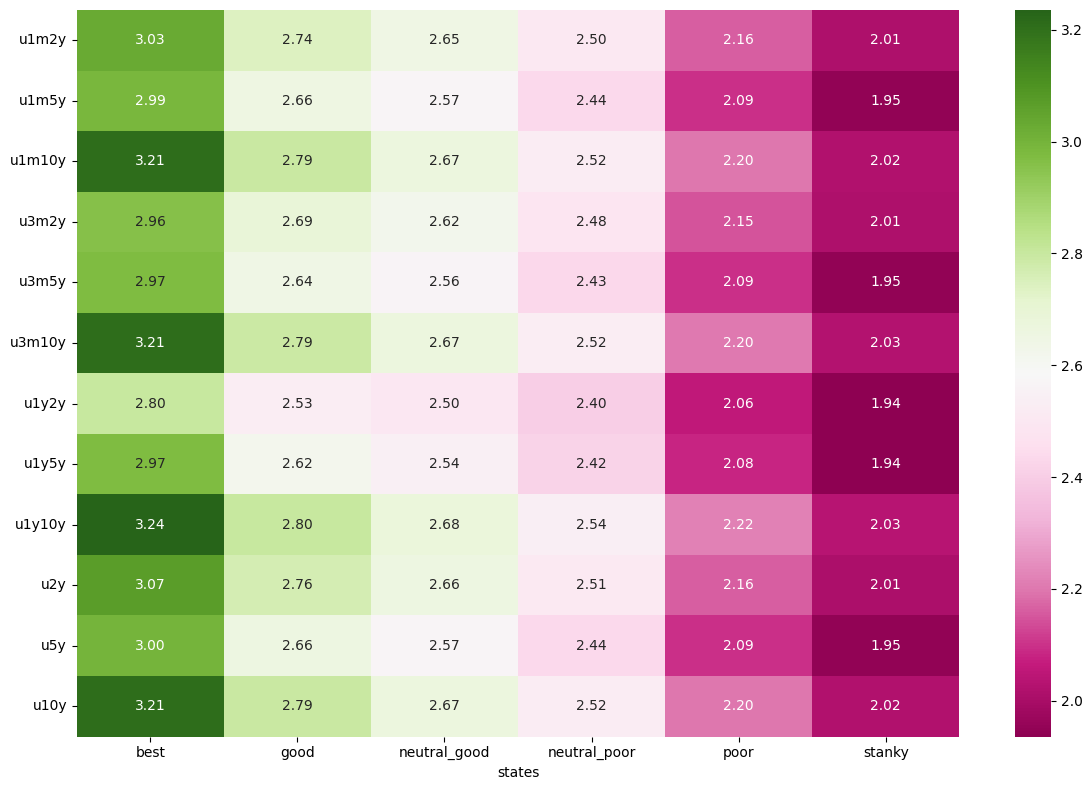

In [484]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(regime_macro_rates.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

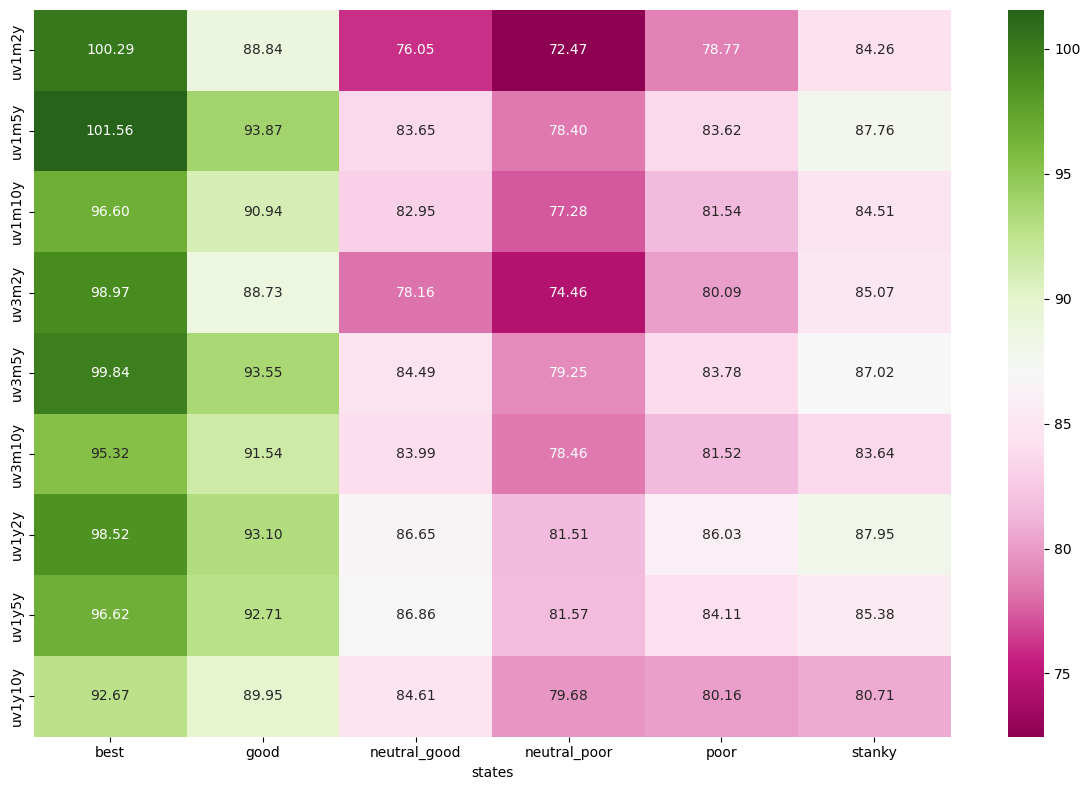

In [485]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(regime_macro_ivs.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

# reason for very high iv, which is associated with very volatile, chaotic market periods. Therefore there needs to be high implied vol, but not so high where we're operating in a illiquid, crisis regime.

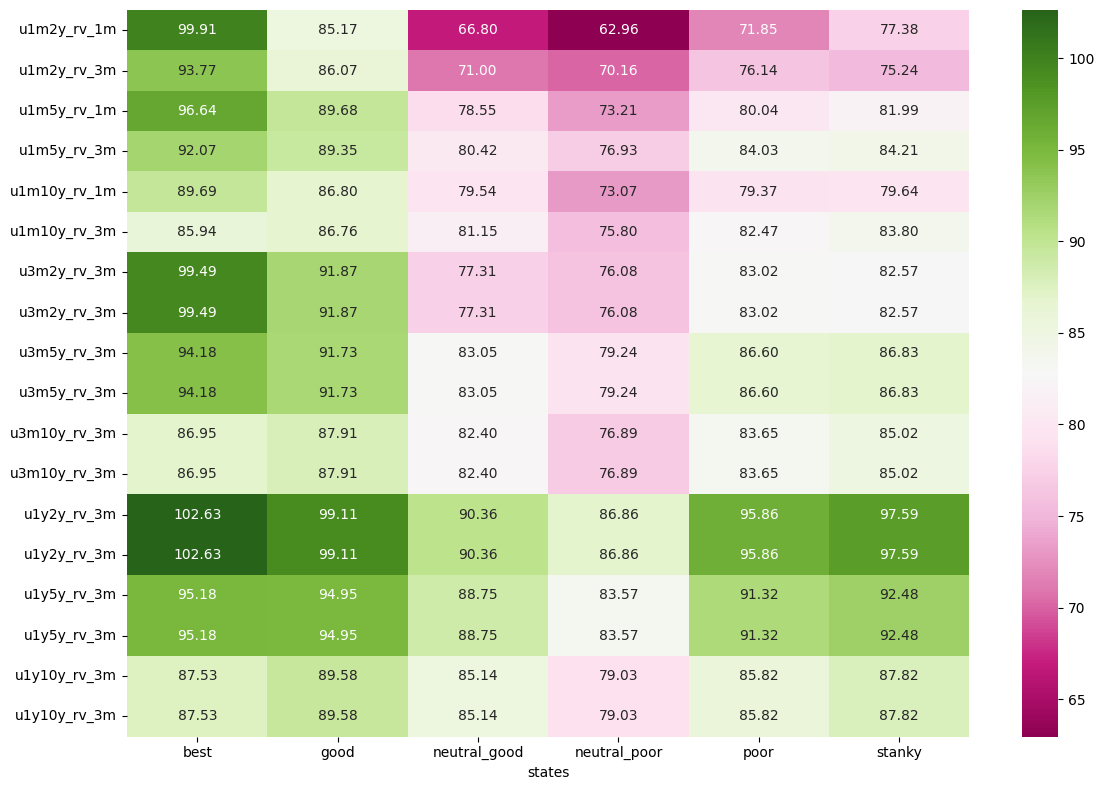

In [486]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(regime_macro_rvs.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

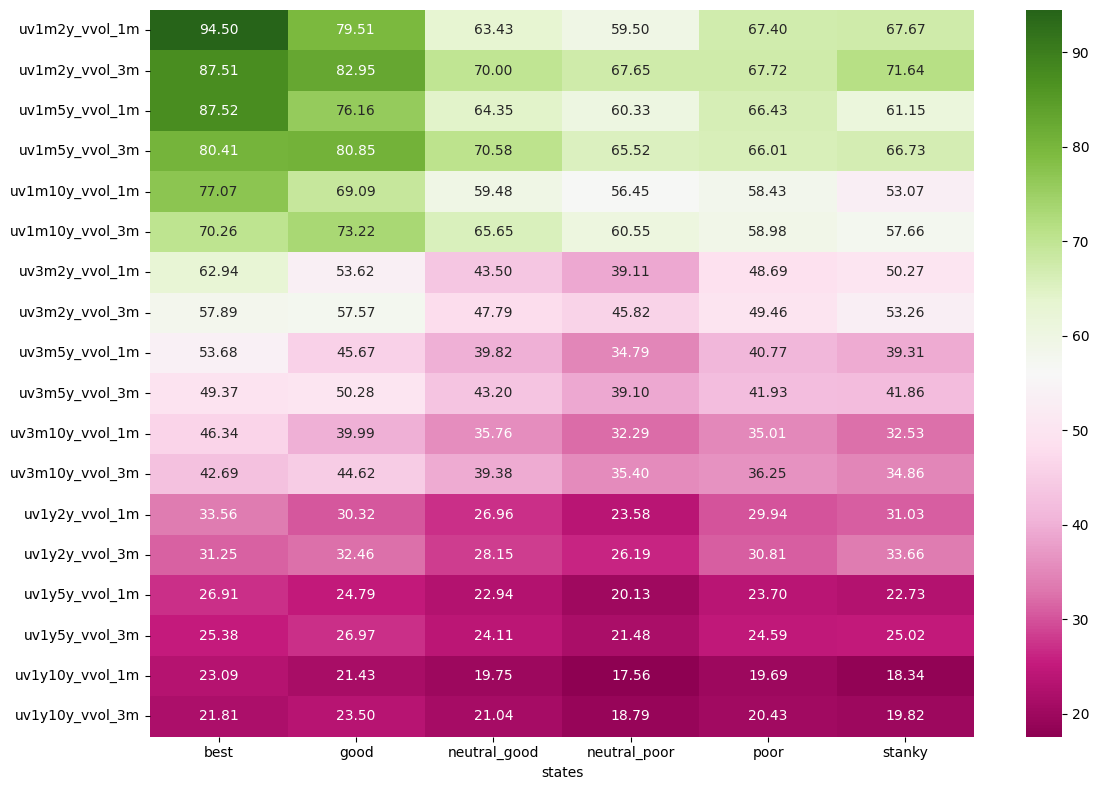

In [487]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(regime_macro_vvol.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

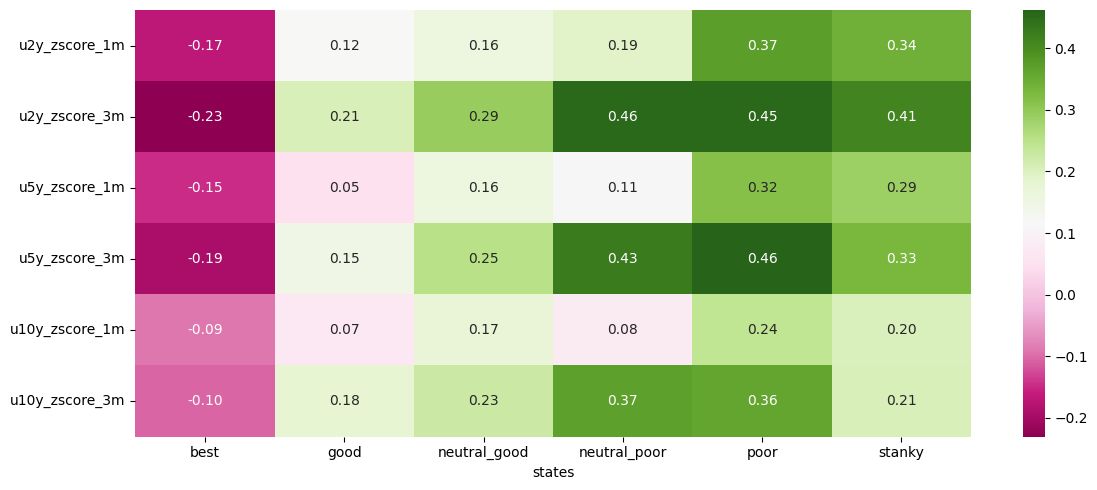

In [488]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(regime_macro_rates_zscore.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

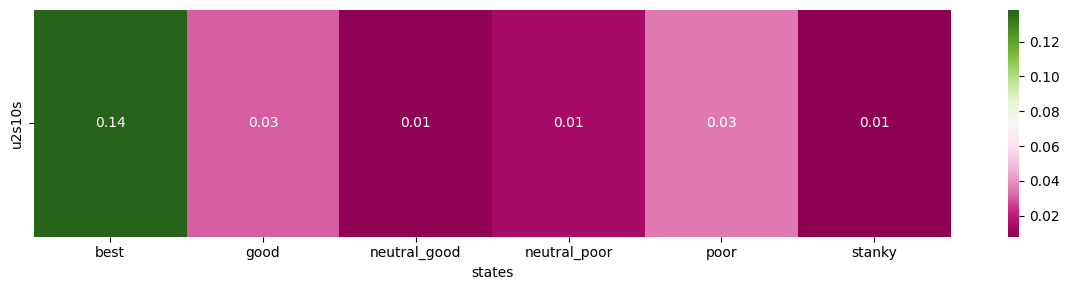

In [489]:
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(regime_macro_u2s10s.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

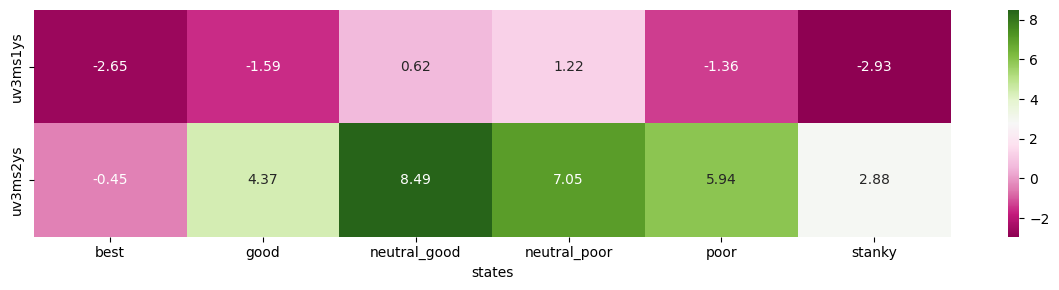

In [490]:
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(regime_macro_vol_curve.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

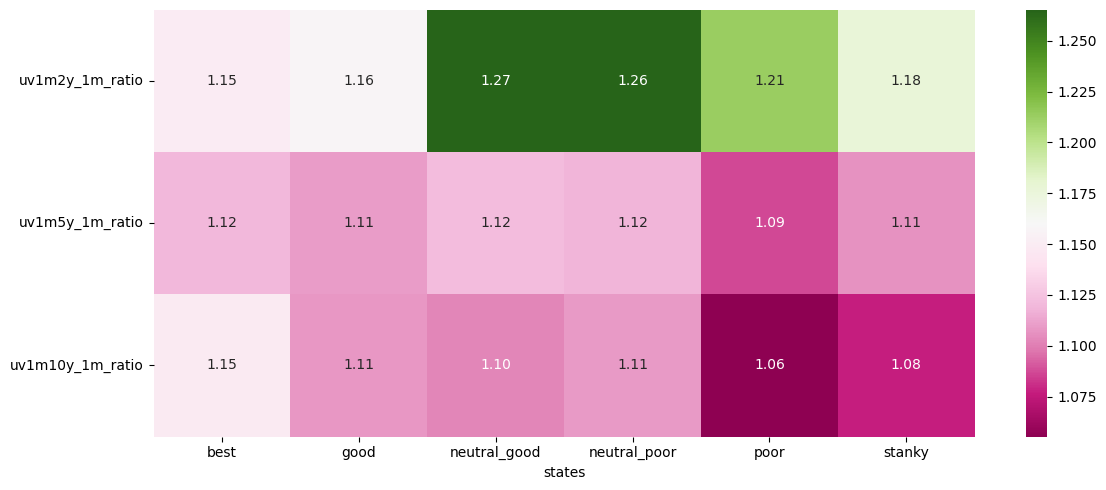

In [491]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(regime_macro_1m_vrp.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

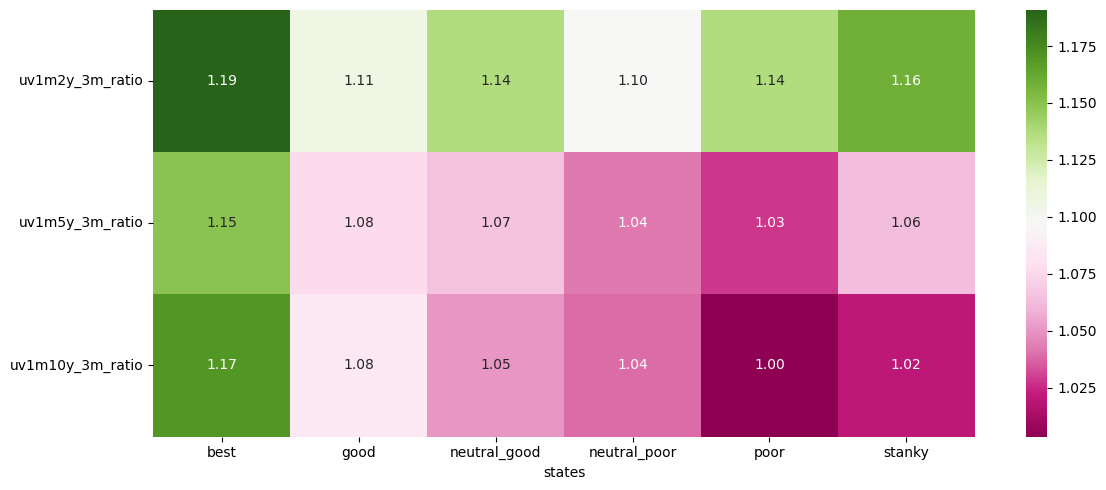

In [492]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(regime_macro_3m_vrp.T, annot=True, fmt='.2f', cmap='PiYG') # regime_macro_rates, regime_macro_ivs, regime_macro_rvs
plt.tight_layout()

## Plot distributions of each variable in best

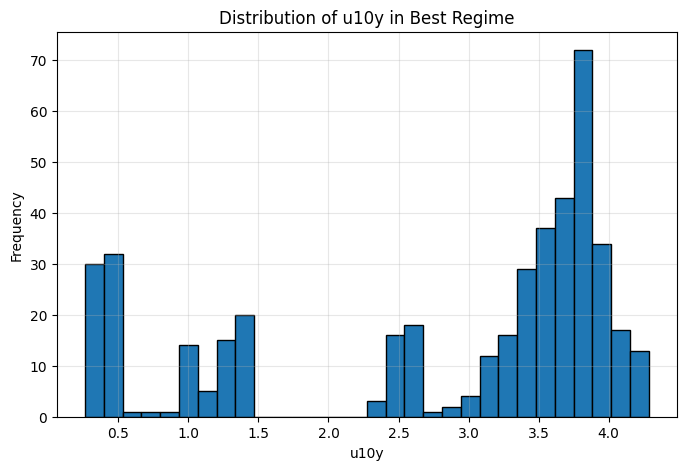

In [503]:
# macro_df[macro_df['states'] == "best"]['u10y'].describe()

plt.figure(figsize=(8, 5))

plt.hist(
    macro_df[macro_df['states'] == "good"]['u10y'],
    bins=30,
    edgecolor="black"
)

plt.xlabel("u10y")
plt.ylabel("Frequency")
plt.title("Distribution of u10y in Best Regime")
plt.grid(alpha=0.3)

plt.show()


## Actually see what variables are statistically significant in explaining the regime level

In [541]:
macro_df

,u10y,u1m10y,u1m2y,u1m5y,u1y10y,u1y2y,u1y5y,u2y,u3m10y,u3m2y,...,u2s10s,uv3ms1ys,uv3ms2ys,uv1m2y_1m_ratio,uv1m2y_3m_ratio,uv1m5y_1m_ratio,uv1m5y_3m_ratio,uv1m10y_1m_ratio,uv1m10y_3m_ratio,states
date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,2.109043,2.117444,1.888239,2.012385,2.176776,2.060211,2.092979,1.859972,2.131971,1.939006,...,0.249071,5.124043,11.011793,1.280600,1.277437,1.155018,1.217851,1.031792,1.163243,poor
2018-01-03,2.096613,2.104579,1.896437,2.013793,2.161508,2.066818,2.091860,1.868524,2.118936,1.947871,...,0.228090,5.640940,11.114278,1.269932,1.218008,1.143795,1.156833,1.029900,1.099442,poor
2018-01-04,2.116153,2.124140,1.925990,2.044630,2.180155,2.108327,2.119267,1.894937,2.138918,1.979940,...,0.221216,6.087501,10.879401,1.232716,1.184715,1.109792,1.125788,1.020528,1.075549,poor
2018-01-05,2.134144,2.142235,1.930974,2.057309,2.199172,2.120300,2.135480,1.899699,2.156892,1.985558,...,0.234445,6.781320,12.013759,1.181785,1.140276,1.071428,1.090160,0.999635,1.038205,poor
2018-01-08,2.137664,2.146402,1.922024,2.054857,2.204057,2.107778,2.136343,1.890096,2.160419,1.973487,...,0.247567,6.672269,11.829948,1.304782,1.173646,1.169833,1.125394,1.059893,1.070207,poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-15,4.066975,4.073622,3.931136,3.913887,4.130199,3.925980,3.947929,3.922646,4.086809,3.944910,...,0.144328,8.816689,7.545652,1.181818,1.051648,1.068328,1.022818,1.061621,1.028970,neutral_poor
2026-06-16,4.019579,4.026255,3.910334,3.875533,4.076734,3.883386,3.897584,3.903066,4.037770,3.919446,...,0.116513,9.368685,8.326961,1.118960,1.027230,1.032628,0.993102,1.024522,0.982564,neutral_poor
2026-06-17,4.050631,4.056505,4.030473,3.947987,4.091492,3.975518,3.946366,4.020214,4.067046,4.042099,...,0.030417,8.548204,6.566155,0.976087,1.000791,0.998832,1.010024,1.058842,1.045479,neutral_poor


## Initial Conclusions and Notes

- Regime 0 achieves the most favorable mean PnL across strategies, 

## Random Forest

Can help us identify what macro variables predict high vs. low PnL. Supervised learning approach

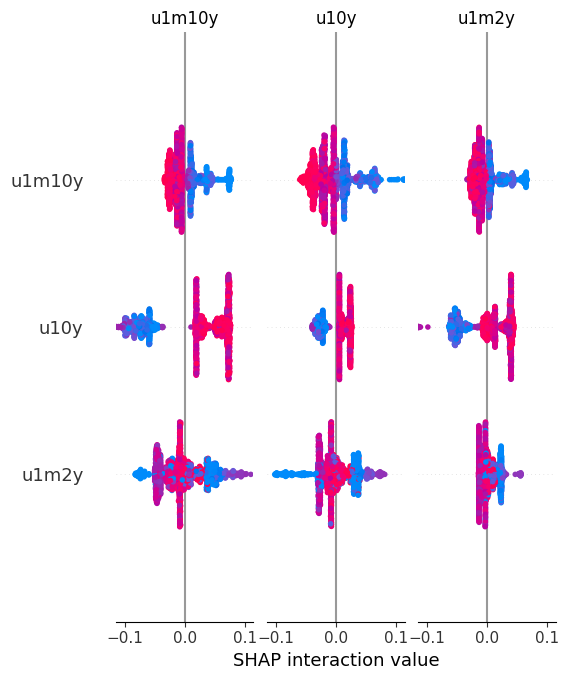

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import shap

pnl_total = pnl_df.sum(axis=1)

labels = pd.qcut(pnl_total, q=3, labels=['low', 'med', 'high'])

# Step 2: Use macro variables as features
aligned = macro_df.join(labels.rename('regime')).dropna()
X = aligned.drop(columns='regime')
y = aligned['regime']

# Step 3: Train classifier
clf = RandomForestClassifier(n_estimators=500, max_depth=5, random_state=42)
clf.fit(X, y)

# Step 4: Explain with SHAP
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)   # ranks features by importance, per regime

In [124]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

pnl_total = pnl_df.sum(axis=1).dropna()

ms_model = MarkovRegression(
    pnl_total, 
    k_regimes=3, 
    trend='c',
    switching_variance=True,
)
res = ms_model.fit()
print(res.summary())

# Smoothed probabilities of being in each regime
smoothed_probs = res.smoothed_marginal_probabilities

c:\Users\s1799275\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\s1799275\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                 2160
Model:               MarkovRegression   Log Likelihood              -19599.903
Date:                Fri, 19 Jun 2026   AIC                          39223.805
Time:                        16:55:21   BIC                          39291.940
Sample:                             0   HQIC                         39248.725
                               - 2160                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        388.7989     24.336     15.976      0.000     341.100     436.498
sigma2      3.971e+05   2.57e+04     15.472      0.0

## Appendix

In [ ]:


scoring_criteria = {"total": 0.5,
                    "mdd": 0.3,
                    "var_95": 0.3,
                    "min": 0.2}

# get mean, std, min, var95 for each metric and rank the most favorable regimes


criteria_list = list(scoring_criteria.keys())

scoring_df = regime_profile_min[criteria_list]
scoring_df_z = (scoring_df - scoring_df.mean()) / scoring_df.std()

criteria_weights = pd.Series(scoring_criteria)
score_df = scoring_df_z * criteria_weights
score_df['composite'] = score_df.sum(axis=1)
score_df = score_df.sort_values('composite', ascending=False)
score_df

,total,mdd,var_95,min,composite
states,,,,,
1,0.280301,0.565272,0.575600,0.397227,1.818399
5,0.052397,-0.002925,0.010286,-0.022913,0.036845
4,0.527279,-0.247268,-0.198724,-0.117134,-0.035847
3,0.335514,-0.070783,-0.198724,-0.117134,-0.051127
0,-0.419566,0.009130,0.010286,-0.022913,-0.423062
2,-0.775924,-0.253425,-0.198724,-0.117134,-1.345207
